In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
import os
import sys
from scipy.interpolate import interp1d
import corner
from radmc3dPy import image
# from CB68.data_dict import data_dict
from make_conti import generate_model
sys.path.append("..")
from profile_radial.make_disk import generate_disk

Fast (Fortran90) Mie-scattering module could not be imported. Falling back to the slower Python version.


In [2]:
def rotate_image(image, posang):
  if isinstance(image, np.ndarray)!=True:
    image.imageJyppix= ndimage.rotate(image.imageJyppix, posang, reshape=False, axes=(1, 0))
    image.imageJyppix = np.nan_to_num(image.imageJyppix, nan=0)
    return image.imageJyppix
  else:
    image = ndimage.rotate(image, posang, reshape=False, axes=(1, 0))
    image = np.nan_to_num(image, nan=0)
    return image
  
def radial_intensity(image_array, center, width):
  radial_profile = np.mean(image_array[:, center-width//2:center+width//2], axis=1)
  return radial_profile

In [3]:
edisk_radial = np.load("edisk_radial.npz")

In [4]:
interp_func = interp1d(np.linspace(0, 1, 190), edisk_radial["i_r"], kind='cubic')
i_r_obs = interp_func(np.linspace(0, 1, 500))

In [5]:
sizeau = 80
npix = 500
pixel_area = (sizeau/npix/140)**2
beam_axis = [0.0363, 0.0274]
beam_area = beam_axis[0]*beam_axis[1]*np.pi/(4*np.log(2))
r_axis = np.linspace(-(sizeau//2), sizeau//2, npix, endpoint=True)

In [ ]:
a_list = [1e-2, 5e-2, 1e-1, 5e-1, 1e0, 1e1]
L_star_list = [1e-1, 5e-1, 1e0, 3e0, 5e0, 1e1]
Q_list = [0.5, 1, 1.5]
mdot_list = [1e-8, 1e-7, 1e-6, 1e-5]


chi_list = []
idx_list = []
def chi(i_r_model, i_r_obs):
    return np.sum(((i_r_model - i_r_obs)**2)/(21e-6**2))

for idx_a, a in enumerate(a_list):
    for idx_l, L_star in enumerate(L_star_list):
        for idx_q, Q in enumerate(Q_list):
            for idx_mdot, mdot in enumerate(mdot_list):
                try:
                    model = generate_model(a, L_star, Q, mdot, heat = "accretion")
                    os.system(f"make cleanall")
                
                    im = image.readImage(fname=f'./test/outfile/conti_a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}_accretion_scat.out')
                    im_conv = im.imConv(dpc=140, fwhm=beam_axis, pa=-69.4)


                    im_conv = rotate_image(im_conv, 45)

                    im_conv *= beam_area/pixel_area/(140**2)
                    

                    i_r = radial_intensity(im_conv, npix//2, 10)
                    interp_func = interp1d(np.linspace(0, 1, 500), i_r[:, 0], kind='cubic')
                    i_r_model = interp_func(np.linspace(0, 1, 190))
                    chi_list.append(chi(i_r_model, edisk_radial["i_r"])*pixel_area/beam_area)
                    idx_list.append((idx_a, idx_l, idx_q, idx_mdot))
                    plt.plot(r_axis, i_r*1e3, label=" radiation model")
                    plt.plot(edisk_radial["r_axis"], edisk_radial["i_r"]*1e3, label="eDisk", linestyle="--")
                    plt.xlim((-(sizeau//2), sizeau//2))
                    plt.ylim(bottom=0)
                    plt.xlabel("Offset (AU)")
                    plt.ylabel("Intensity (mJy/beam)")
                    plt.title(f"Continuum radial profile along the major axis")
                    plt.legend()
                    plt.savefig(f"./figures/a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}_accretion.pdf", transparent=True)
                    plt.close("all")
                except:
                    pass



In [21]:
print(idx_list[chi_list.index(min(chi_list))])
a_best_idx, L_star_best_idx, Q_best_idx, mdot_best_idx = idx_list[chi_list.index(min(chi_list))]
a_best = a_list[a_best_idx]
L_star_best = L_star_list[L_star_best_idx]
Q_best = Q_list[Q_best_idx]
mdot_best = mdot_list[mdot_best_idx]
print(f"Maximum grain size: {a_best} mm")
print(f"Stellar luminosity: {L_star_best} Lsun")
print(f"Toomre Q: {Q_best}")
print(f"Mass accretion rate: {mdot_best} Msun/yr")

(2, 5, 0, 3)
Maximum grain size: 0.1 mm
Stellar luminosity: 10.0 Lsun
Toomre Q: 0.5
Mass accretion rate: 1e-05 Msun/yr


In [22]:
disk_best = generate_disk(
    amax   = a_best,
    mstar  = 0.14,
    mdot   = mdot_best,
    rd     = 25,
    Q      = Q_best,
    l_star = L_star_best,
    r_star = 1,
    heat   = "accretion",
    dir="./disk_best_acc/"
)

You have 24 Processors


In [23]:
from radmc3dPy.analyze import *
def read_from_dir(dir):
    os.chdir(dir)
    d = readData(dtemp=True, ddens=True, gdens=True, ispec='ch3oh')
    grid = readGrid(wgrid=False)
    os.chdir('..')
    return d, grid

In [10]:
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
def plot_profile(d, grid):
    nch3oh    = d.ndens_mol[:, :, 0, 0]
    dust      = np.sum(d.rhodust[:, :, 0, :], axis=2)
    t         = np.mean(d.dusttemp[:, :, 0, :], axis=2)
    R, Theta, Phi =  grid.x/au, grid.y, grid.z
    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(18, 6),
                        subplot_kw={'projection': 'polar'})
    fig.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.1, wspace=0.3, hspace=0.05)
    cmaps = ['BuPu', 'OrRd', 'BuPu']
    titles = [r'$\rho_{dust}$', r'$T$', r'$n_{\mathregular{CH_3OH}}$']
    cbar = [r'log($\rho$) [g$cm^{-3}$]', r'log(T) [K]',r'log($n_{\mathregular{CH_3OH}}$) [$cm^{-3}$]']

    for idx_val, val in enumerate([dust, t, nch3oh]):
        c = ax[idx_val].pcolormesh(Theta-np.pi/2, R, np.log10(val), shading='auto', cmap=cmaps[idx_val])
        ax[idx_val].pcolormesh(Theta+np.pi/2, R, np.log10(val), shading='auto', cmap=cmaps[idx_val])
        if idx_val == 0:
            den = val
            # levels = np.linspace(np.log10(den).min(), np.log10(den).max(), 3)
            levels = [-20, -17, -14]
        ax[idx_val].contour(Theta-np.pi/2, R, np.log10(den), levels=levels, colors='k', linewidths=.7, linestyles='dashed')
        ax[idx_val].contour(Theta+np.pi/2, R, np.log10(den), levels=levels, colors='k', linewidths=.7, linestyles='dashed')
        ax[idx_val].set_xticks([])
        ax[idx_val].set_yticks([])
        fig.colorbar(c, ax=ax[idx_val], orientation='vertical', shrink=0.7).set_label(cbar[idx_val], fontsize=18)
        ax[idx_val].set_title(titles[idx_val], fontsize=26, color='k')


    scale_bar_ax = fig.add_axes([0.48, 0.12, 0.09, 0.02]) # [left, bottom, width, height]
    scale_bar = AnchoredSizeBar(scale_bar_ax.transData,
                                1,  # Size of the scale bar in data coordinates
                                f'{round(R[-1])} AU',  # Label for the scale bar
                                'lower center',  # Location
                                pad=0.1,
                                color='black',
                                frameon=False,
                                size_vertical=0.01,
                                fontproperties=fm.FontProperties(size=12))

    scale_bar_ax.add_artist(scale_bar)
    scale_bar_ax.set_axis_off()

    scale_bar_ax = fig.add_axes([0.15, 0.12, 0.09, 0.02]) # [left, bottom, width, height]
    scale_bar = AnchoredSizeBar(scale_bar_ax.transData,
                                1,  # Size of the scale bar in data coordinates
                                f'{round(R[-1])} AU',  # Label for the scale bar
                                'lower center',  # Location
                                pad=0.1,
                                color='black',
                                frameon=False,
                                size_vertical=0.01,
                                fontproperties=fm.FontProperties(size=12))

    scale_bar_ax.add_artist(scale_bar)
    scale_bar_ax.set_axis_off()

    scale_bar_ax = fig.add_axes([0.8, 0.12, 0.09, 0.02]) # [left, bottom, width, height]
    scale_bar = AnchoredSizeBar(scale_bar_ax.transData,
                                1,  # Size of the scale bar in data coordinates
                                f'{round(R[-1])} AU',  # Label for the scale bar
                                'lower center',  # Location
                                pad=0.1,
                                color='black',
                                frameon=False,
                                size_vertical=0.01,
                                fontproperties=fm.FontProperties(size=12))

    scale_bar_ax.add_artist(scale_bar)
    scale_bar_ax.set_axis_off()

In [24]:
d_beat, grid = read_from_dir("./disk_best_acc/")

Reading amr_grid.inp
Reading wavelength_micron.inp
Reading dust_density.inp
Reading dust_temperature.dat
Reading gas density (numberdens_ch3oh.inp)
Reading amr_grid.inp


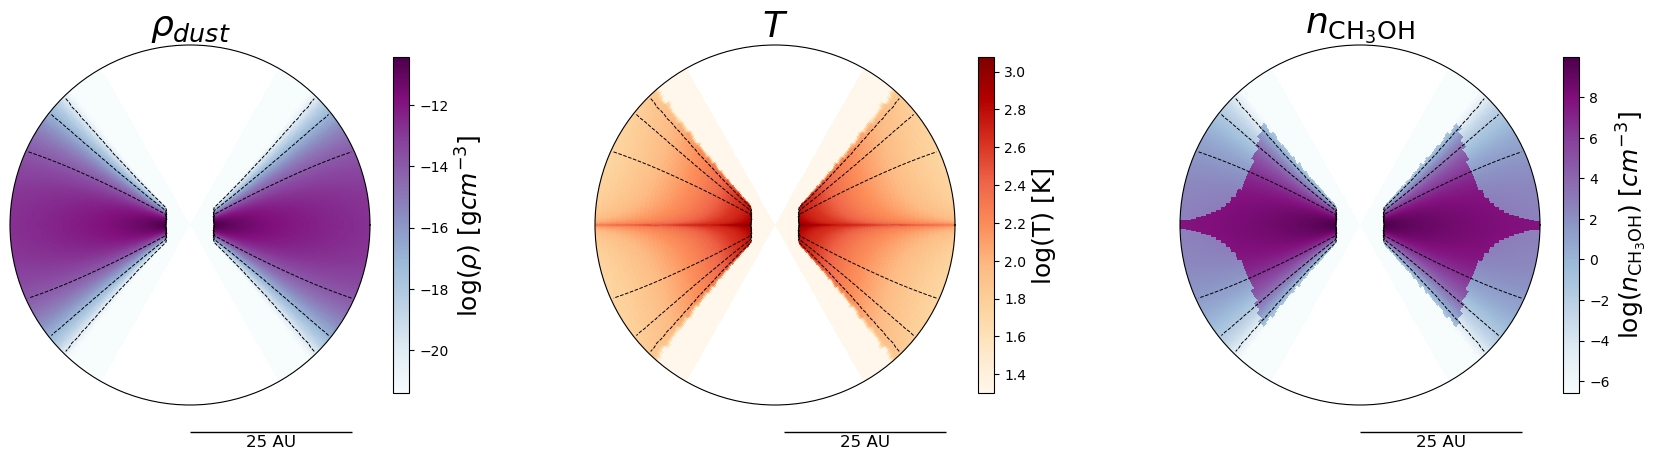

In [25]:
plot_profile(d_beat, grid)

In [26]:
im = image.readImage(fname=f'./test/outfile/conti_a_{a_best}_Lstar_{L_star_best}_Q_{Q_best}_mdot_{mdot_best}_accretion_scat.out')
im_conv = im.imConv(dpc=140, fwhm=beam_axis, pa=-69.4)


im_conv = rotate_image(im_conv, 45)

im_conv *= beam_area/pixel_area/(140**2)

Reading ./test/outfile/conti_a_0.1_Lstar_10.0_Q_0.5_mdot_1e-05_accretion_scat.out


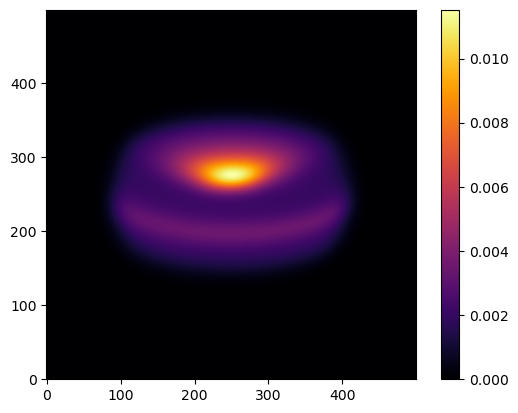

In [27]:
plt.imshow(im_conv[:,:,0].T, origin='lower', cmap="inferno")
plt.colorbar()


In [15]:
# color_val = np.log(chi_list)


In [16]:
# fig, ax = plt.subplots(1, 6, figsize=(20, 4))
# for idx_a, a in enumerate(a_list):
#     for idx_l, L_star in enumerate(L_star_list):
#         for idx_q, Q in enumerate(Q_list):
#             for idx_mdot, mdot in enumerate(mdot_list):
#                 chi = np.log(chi_list[idx_list.index((idx_a, idx_l, idx_q, idx_mdot))])
#                 ax[0].scatter(a, L_star, c=chi, cmap="RdBu",vmin=color_val.min(), vmax=color_val.max(), alpha=0.3)
#                 ax[1].scatter(a, Q, c=chi, cmap="RdBu",vmin=color_val.min(), vmax=color_val.max(), alpha=0.3)
#                 ax[2].scatter(a, mdot, c=chi, cmap="RdBu",vmin=color_val.min(), vmax=color_val.max(), alpha=0.3)
#                 ax[3].scatter(L_star, Q, c=chi, cmap="RdBu",vmin=color_val.min(), vmax=color_val.max(), alpha=0.3)
#                 ax[4].scatter(L_star, mdot, c=chi, cmap="RdBu",vmin=color_val.min(), vmax=color_val.max(), alpha=0.3)
#                 ax[5].scatter(Q, mdot, c=chi, cmap="RdBu",vmin=color_val.min(), vmax=color_val.max(), alpha=0.3)
#                 ax[0].set_yscale("log");ax[0].set_xscale("log")
#                 ax[1].set_yscale("log");ax[1].set_xscale("log")
#                 ax[2].set_yscale("log");ax[2].set_xscale("log")
#                 ax[3].set_yscale("log");ax[3].set_xscale("log")
#                 ax[4].set_yscale("log");ax[4].set_xscale("log")
#                 ax[5].set_yscale("log");ax[5].set_xscale("log")
                

In [17]:
# a = 1e-2
# L_star = 3e0
# Q = 1
# mdot = 1e-6
# heat = "irradiation"
# generate_model(a, L_star, Q, mdot, heat)


In [18]:
# im = image.readImage(fname=f'./test/outfile/conti_a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}_{heat}_scat.out')
# im_conv = im.imConv(dpc=140, fwhm=beam_axis, pa=-69.4)


# im_conv = rotate_image(im_conv, 45)

# im_conv *= beam_area/pixel_area/(140**2)
# # T_b = 1.36*(1.3e-1)**2/(beam_axis[0]*beam_axis[1])*im_conv*1e3
# # # print(1.36*(1.3e-1)**2/(beam_axis[0]*beam_axis[1])*3)
# plt.imshow(im_conv[:,:,0].T, origin="lower", cmap="inferno")
# plt.colorbar()
# plt.show()

In [19]:
# edisk_radial = np.load("edisk_radial.npz")


In [20]:
# i_r = radial_intensity(im_conv, npix//2, 10)
# plt.plot(r_axis, i_r*1e3, label="Model")
# plt.plot(edisk_radial["r_axis"], edisk_radial["i_r"]*1e3, label="eDisk", linestyle="--")
# plt.xlim((-(sizeau//2), sizeau//2))
# plt.ylim(bottom=0)
# plt.xlabel("Offset (AU)")
# plt.ylabel("Intensity (mJy/beam)")
# plt.title(f"Continuum radial profile along the major axis")
# plt.legend()